#Projet final de Modélisation Numérique en Physique


##Simulation et optimisation d'une trajectoire de la Terre à Mars

*Elisa Leblond 21302500*

## Introduction :

L'exploration de Mars représente l'un des défis majeurs de l'exploration spatiale actuelle. L'un des aspects essentiels de ce type de mission est la planification rigoureuse de la trajectoire que devra suivre un satellite ou une sonde pour quitter la Terre et atteindre Mars avec précision. Ce défi implique une compréhension des lois de la mécanique céleste et une prise en compte des contraintes associées aux transferts interplanétaires.
Ce projet vise à simuler numériquement un transfert Terre-Mars en modélisant le système solaire à l'aide d'un modèle à trois corps (Soleil, Terre, Mars), complété par un satellite de masse négligeable. L'objectif est de déterminer les conditions optimales, en termes de jour de lancement et de vitesse initiale permettant une rencontre rapprochée avec Mars.
Pour cela, nous avons développé un modèle gravitationnel basé sur la loi de Newton, en choissant un référentiel héliocentrique. Le satellite est lancé tangentiellement à l'orbite terrestre, avec une vitesse initiale.
Les positions et vitesses initiales de la Terre et de Mars sont déterminées à partir de données réelles (JPL Horizons) à la date du 1er avril 2025. Les distances sont exprimées en unités astronomiques (UA), les temps en années, et les vitesses sont converties en UA/an.
Nous utilisons la méthode numérique "Leapfrog" pour intégrer les équations du mouvement. Pour chaque couple (jour de lancement, vitesse), nous simulons la trajectoire du satellite et extrayons trois quantités principales: la distance minimale au voisinage de Mars, le temps de vol, et la vitesse relative lors de l'approche.
Cette approche nous permet d'identifier des conditions de lancement réalistes et efficaces, tout en visualisant des trajectoires physiquement possibles. Nous pourrons ainsi comparer nos résultats à des missions réelles et proposer des pistes d'amélioration.

## Définition du modèle :
Le système étudié est modélisé dans un référentiel héliocentrique, dans lequel le Soleil est considéré fixe.
Afin de simplifier le problème, nous posons plusieurs hypothèses. Le satellite n'exerce aucune force sur les autres corps, et il n'est soumis à aucune propulsion continue après son lancement. De plus, les effets comme la résistance atmosphérique ou les perturbations gravitationnelles dues à d'autres planètes sont négligés.
Pour faciliter le calcul, la masse du Soleil est prise comme unité de référence ($M_S = 1$).

## Loi de la gravitation universelle

Le mouvement des corps dans notre modèle est régi par la loi de la gravitation universelle de Newton, qui décrit l'attraction exercée entre deux masses ponctuelles.

La force gravitationnelle exercée par un corps $j$ sur un corps $i$ est donnée par :

$$
\vec{F}_{ij} = G \cdot \frac{m_i m_j}{r_{ij}^2} \cdot \hat{r}_{ij}
$$

où :
- $m_i$ et $m_j$ sont les masses respectives des corps $i$ et $j$,
- $\vec{r}_{ij} = \vec{r}_j - \vec{r}_i$ est le vecteur qui relie $i$ à $j$,
- $\hat{r}_{ij}$ est le vecteur unitaire associé à $\vec{r}_{ij}$,
- $G$ est la constante gravitationnelle, ici exprimée en unités astronomiques : $G = 4\pi^2$ (UA³/an²/M☉).

En divisant cette force par la masse du corps $i$, on obtient l'accélération gravitationnelle qu’il subit :

$$
\vec{a}_i = \sum_{j \ne i} G \cdot \frac{m_j}{r_{ij}^3} \cdot \vec{r}_{ij}
$$

Cette relation vectorielle exprime que chaque corps est accéléré sous l'effet de la somme des forces gravitationnelles exercées par les autres. Ces accélérations sont ensuite intégrées numériquement pour obtenir la trajectoire de chaque corps.


## Méthode numérique : Leapfrog (Verlet)

Pour résoudre les équations du mouvement gravitationnel, nous devons intégrer numériquement un système d'équations différentielles de la forme :

$$
\frac{d\vec{r}_i}{dt} = \vec{v}_i, \quad \frac{d\vec{v}_i}{dt} = \vec{a}_i(\vec{r})
$$

Nous utilisons pour cela la méthode de Leapfrog, aussi appelée méthode de Verlet en vitesse, qui est particulièrement adaptée aux systèmes hamiltoniens tels que les systèmes gravitationnels. Elle se distingue par sa capacité à conserver l'énergie mécanique sur le long terme, ce qui est essentiel pour obtenir des trajectoires orbitales stables.

Le principe du Leapfrog repose sur un décalage temporel entre les mises à jour de la position et de la vitesse. À chaque pas de temps $\Delta t$, on effectue les opérations suivantes :

1. Mise à jour de la vitesse à mi-pas :

$$
\vec{v}_i^{n+\frac{1}{2}} = \vec{v}_i^{n} + \frac{\Delta t}{2} \cdot \vec{a}_i^{n}
$$

2. Mise à jour de la position :

$$
\vec{r}_i^{n+1} = \vec{r}_i^{n} + \Delta t \cdot \vec{v}_i^{n+\frac{1}{2}}
$$

3. Mise à jour finale de la vitesse :

$$
\vec{v}_i^{n+1} = \vec{v}_i^{n+\frac{1}{2}} + \frac{\Delta t}{2} \cdot \vec{a}_i^{n+1}
$$

Ces trois étapes permettent à la méthode d'être simple, rapide, et surtout très stable, même pour de longues simulations.

Nous verrons par la suite qu'il existe d'autres méthodes comme la méthode Runge-Kutta, qui du aux simplications de notre modèle donne le même résultat.



In [1]:
#Importation des bibliothèques et des modules nécéssaires
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Constantes
G = 4 * np.pi**2  #Constante gravitationnelle en UA^3 / an^2 / masse solaire

On définit une classe qui représente un objet céleste (planète, Soleil ou satellite). Elle stocke sa masse, sa position, sa vitesse et son accélération à chaque instant. En utilisant une classe, on peut facilement regrouper toutes les informations d'un même corps et les manipuler lors des calculs d'évolution du système.

In [3]:
class Corps:
    def __init__(self, nom, masse, position, vitesse):
        self.nom = nom
        self.masse = masse
        self.position = np.array(position, dtype=float)
        self.vitesse = np.array(vitesse, dtype=float)
        self.acceleration = np.zeros(2)


On calcule l'accélération gravitationnelle subie par chaque corps
en tenant compte des forces exercées par tous les autres corps. Cette fonction est appelée à chaque étape de l'intégration pour mettre à jour les accélérations utilisées, et ensuite pour mettre à jour les vitesses et positions.


In [9]:
def calculer_accelerations(corps_list):
    #Pour chaque corps du système
    for corps in corps_list:
        #On initialise l'accélération à zéro (vecteur 2D)
        acc = np.zeros(2)
        for autre in corps_list:
            if autre != corps:
                #Vecteur allant du corps actuel vers l'autre corps
                r = autre.position - corps.position
                #Distance entre les deux corps
                d = np.linalg.norm(r)
                if d > 0:  #on évite une division par zéro
                    acc += G * autre.masse * r / d**3
        corps.acceleration = acc


Cette fonction implémente la méthode d'intégration numérique Leapfrog (Verlet).

In [10]:
def leapfrog(corps_list, dt):
    #on met à jour des vitesses à mi-pas
    for corps in corps_list:
        corps.vitesse += 0.5 * corps.acceleration * dt
    #on met à jour des positions
    for corps in corps_list:
        corps.position += corps.vitesse * dt
    #on recalcule des accélérations
    calculer_accelerations(corps_list)
    #on met à nouveau à jour des vitesses
    for corps in corps_list:
        corps.vitesse += 0.5 * corps.acceleration * dt



On initialise les positions et vitesses des corps du système (Soleil, Terre, Mars, Satellite) en fonction d'un jour de lancement et d'une vitesse initiale donnée au satellite. On utilise des positions réalistes au 1er avril 2025 et effectue une rotation pour simuler la position des planètes à n'importe quel jour de l'année.

In [5]:
def initialisation_systeme(jour_lancement, vitesse_kms):
    #Conversion de la vitesse donnée en km/s vers les unités internes du modèle : UA/an
    UA = 1.496e8  # 1 unité astronomique en km
    an_sec = 365.25 * 24 * 3600  # nombre de secondes dans une année
    vitesse_UA_par_an = vitesse_kms * an_sec / UA

    #Données initiales issues de JPL Horizons au 1er avril 2025
    #Positions et vitesses de la Terre et de Mars à cette date
    terre_pos_ref = np.array([0.987, 0.161])
    terre_vit_ref = np.array([-1.089, 6.571])
    mars_pos_ref = np.array([-1.332, 0.491])
    mars_vit_ref = np.array([-3.392, -2.278])

    #Rotation des positions et vitesses selon le jour de lancement
    angle_terre = 2 * np.pi * jour_lancement / 365.25  #période orbitale de la Terre
    R_T = np.array([[np.cos(angle_terre), -np.sin(angle_terre)],
                    [np.sin(angle_terre),  np.cos(angle_terre)]])
    pos_terre = R_T @ terre_pos_ref
    vit_terre = R_T @ terre_vit_ref

    angle_mars = 2 * np.pi * jour_lancement / 687  # période orbitale de Mars
    R_M = np.array([[np.cos(angle_mars), -np.sin(angle_mars)],
                    [np.sin(angle_mars),  np.cos(angle_mars)]])
    pos_mars = R_M @ mars_pos_ref
    vit_mars = R_M @ mars_vit_ref

    #Calcul de la vitesse du satellite
    direction = vit_terre / np.linalg.norm(vit_terre)  # vecteur unitaire tangent à l'orbite
    vit_satellite = vit_terre + direction * vitesse_UA_par_an

    #Initialisation des corps du système : Soleil, Terre, Mars, Satellite
    soleil = Corps("Soleil", 1.0, [0, 0], [0, 0])  # masse normalisée
    terre = Corps("Terre", 3.003e-6, pos_terre, vit_terre)
    mars = Corps("Mars", 3.213e-7, pos_mars, vit_mars)
    satellite = Corps("Satellite", 0.0, pos_terre.copy(), vit_satellite)  # masse nulle

    return [soleil, terre, mars, satellite]


## Simulation :

Avant de lancer une simulation complète, nous cherchons à identifier les conditions de lancement optimales permettant une rencontre rapprochée avec Mars. Deux paramètres principaux sont étudiés : le jour de lancement, compté à partir du 1er avril 2025, et la vitesse initiale du satellite, exprimée en km/s et ajoutée tangentiellement à l'orbite terrestre. L'objectif est de minimiser la distance d'approche entre le satellite et Mars, tout en maintenant une vitesse relative suffisamment faible pour permettre une insertion orbitale réaliste.

Pour cela, nous effectuons une exploration paramétrique en deux étapes. Nous commençons par faire varier le jour de lancement pour une vitesse fixée (par exemple 3.2 km/s) puis nous faisons varier la vitesse initiale pour un jour de lancement choisi. À chaque simulation, nous extrayons les quantités physiques pertinentes: la distance minimale entre Mars et le satellite ainsi que leur vitesse relative au moment de l'approche. Cela nous permettra d'identifier un compromis réaliste et efficace, physiquement crédible et cohérent avec un scénario de transfert interplanétaire.


La vitesse initiale de 3.2 km/s a été déterminée par balayage, tout en notant que la vitesse théorique ultisée lors de missions réelles et 3.22 km/s.

In [7]:
def simulation_distance_minimale(jour_lancement, vitesse_kms, N=2000, dt=0.002):
    #Conversion des unités
    UA = 1.496e8  # km
    an_sec = 365.25 * 24 * 3600  # secondes dans une année

    #Initialisation du système au jour et à la vitesse choisis
    corps = initialisation_systeme(jour_lancement, vitesse_kms)
    calculer_accelerations(corps)  #initialisation des accélérations

    distances = []        #Liste des distances satellite-Mars à chaque pas de temps
    vitesses_relat = []   #Liste des vitesses relatives satellite-Mars

    for _ in range(N):
        leapfrog(corps, dt)  #mise à jour des positions et vitesses
        mars = next(c for c in corps if c.nom == "Mars")
        satellite = next(c for c in corps if c.nom == "Satellite")

        #Distance instantanée entre satellite et Mars
        distances.append(np.linalg.norm(mars.position - satellite.position))

        #Vitesse relative instantanée
        vit_rel = np.linalg.norm(mars.vitesse - satellite.vitesse)
        vitesses_relat.append(vit_rel)

    # Extraction de la distance minimale et des grandeurs associées
    i_min = np.argmin(distances)  # indice de la distance minimale
    distance_min = distances[i_min]
    temps_rencontre = i_min * dt  # converti directement en années
    vitesse_relative = vitesses_relat[i_min] * UA / an_sec  # conversion de UA/an → km/s

    return distance_min, temps_rencontre, vitesse_relative


On trouve le meilleur jour de lancement à vitesse fixe
en calculant la distance minimale entre le satellite et Mars pour chaque jour.


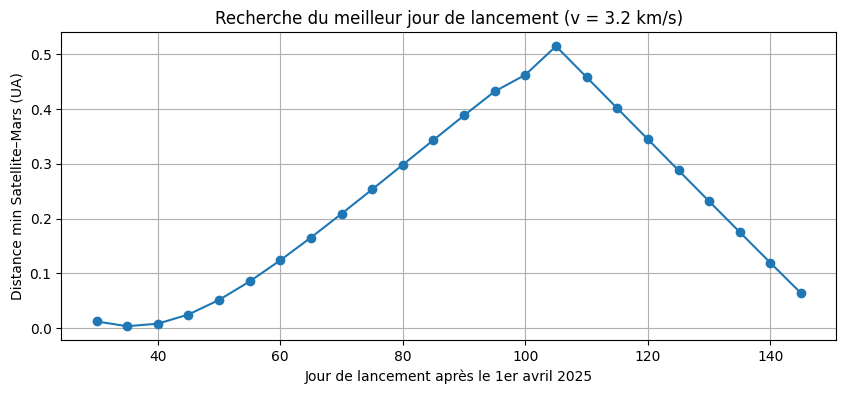

Meilleur jour de lancement : 35
Distance minimale obtenue : 0.0034 UA


In [11]:
#Balayage des jours de lancement entre les jours 30 et 145 après le 1er avril 2025
jours = np.arange(30, 150, 5)  # pas de 5 jours
distances = []

#Simulation pour chaque jour avec vitesse fixe de 3.2 km/s
for j in jours:
    dmin, _, _ = simulation_distance_minimale(j, 3.2)
    distances.append(dmin)

#Graphique de la distance minimale en fonction du jour de lancement
plt.figure(figsize=(10, 4))
plt.plot(jours, distances, marker='o')
plt.xlabel("Jour de lancement après le 1er avril 2025")
plt.ylabel("Distance min Satellite–Mars (UA)")
plt.title("Recherche du meilleur jour de lancement (v = 3.2 km/s)")
plt.grid(True)
plt.show()

#Affichage des résultats
index_min = np.argmin(distances)
meilleur_jour = jours[index_min]
meilleure_distance = distances[index_min]

print(f"Meilleur jour de lancement : {meilleur_jour}")
print(f"Distance minimale obtenue : {meilleure_distance:.4f} UA")


Dans cette partie, nous effectuons une première simulation complète à l'aide de paramètres standards : le satellite est lancé le 35ᵉ jour après le 1er avril 2025, soit le 10 mai, avec une vitesse initiale de 3.2 km/s ajoutée tangentiellement à la trajectoire terrestre. La trajectoire du satellite est alors intégrée dans le référentiel héliocentrique, en tenant compte des interactions gravitationnelles avec le Soleil, la Terre et Mars. À partir de cette simulation, nous analysons trois grandeurs physiques essentielles : la distance minimale atteinte entre le satellite et Mars au cours du trajet, le temps nécessaire pour atteindre ce point d’approche, ainsi que la vitesse relative entre les deux corps à cet instant. Ces résultats permettent d’évaluer l’efficacité de la trajectoire et d’envisager la faisabilité d’une insertion orbitale autour de Mars.


La fonction suivante permet de simuler la trajectoire complète du satellite.


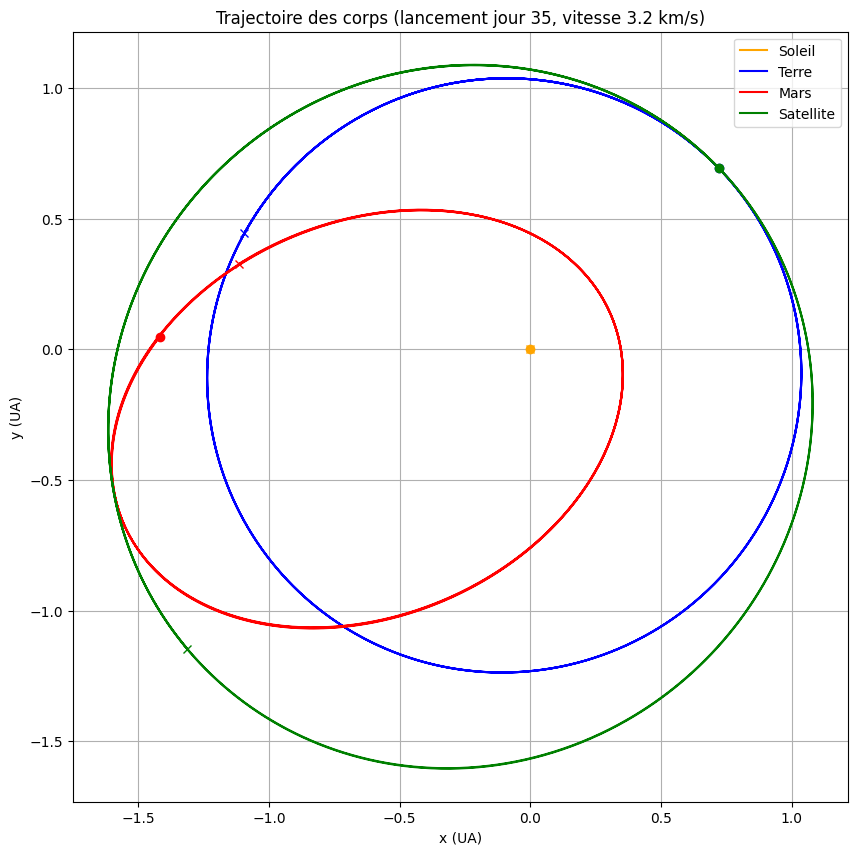

In [12]:
def simuler_trajectoire(jour_lancement=35, vitesse_kms=3.2, N=2000, dt=0.002):

    #Initialisation
    corps = initialisation_systeme(jour_lancement, vitesse_kms)
    calculer_accelerations(corps)

    #Dictionnaire pour stocker les positions de chaque corps à chaque pas de temps
    positions = {c.nom: [] for c in corps}


    for _ in range(N):
        for c in corps:
            positions[c.nom].append(c.position.copy())
        leapfrog(corps, dt)  #mise à jour des positions/vitesses

    #On trace les trajectoires
    plt.figure(figsize=(10, 10))
    couleurs = {"Soleil": "orange", "Terre": "blue", "Mars": "red", "Satellite": "green"}

    for nom, traj in positions.items():
        traj = np.array(traj)
        plt.plot(traj[:, 0], traj[:, 1], label=nom, color=couleurs[nom])        # trajectoire
        plt.plot(traj[0, 0], traj[0, 1], marker='o', color=couleurs[nom])       #point de départ
        plt.plot(traj[-1, 0], traj[-1, 1], marker='x', color=couleurs[nom])     #point d'arrivée

    #Ajout du titre et des légendes
    plt.xlabel("x (UA)")
    plt.ylabel("y (UA)")
    plt.title("Trajectoire des corps (lancement jour 35, vitesse 3.2 km/s)")
    plt.legend()
    plt.axis("equal")
    plt.grid()
    plt.show()

simuler_trajectoire()


Le graphique représente l'évolution des trajectoires du satellite, de la Terre et de Mars dans un référentiel héliocentrique. Le satellite (en vert) est lancé depuis la Terre (en bleu) avec une vitesse initiale supplémentaire de 3.2 km/s, ajoutée tangentiellement à sa trajectoire orbitale. Sous l'effet de la gravitation solaire, il suit une trajectoire elliptique modifiée par la présence des deux planètes. L'orbite de Mars (en rouge), bien que légèrement elliptique (excentricité ≈ 0.093), conserve une structure régulière qui permet de visualiser clairement les moments de rapprochement. L'objectif du transfert est que les trajectoires du satellite et de Mars se croisent à la fois dans l'espace et dans le temps, condition nécessaire pour envisager une rencontre effective. Sur le graphique, le point de croisement marqué met en évidence un rapprochement significatif entre les deux corps, que nous allons quantifier plus précisément dans la suite du projet.


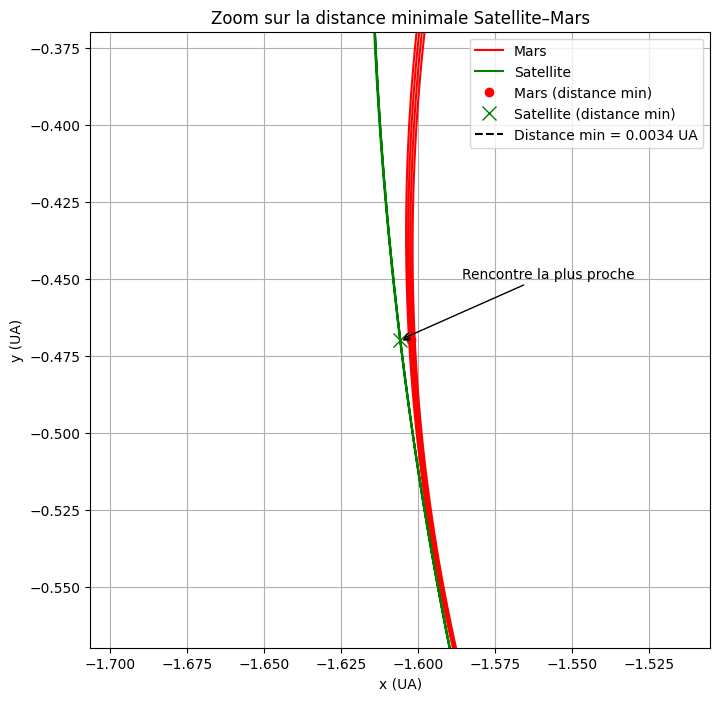

In [13]:
def rencontre_min_distance(jour_lancement=35, vitesse_kms=3.2, N=2000, dt=0.002):
    #Initialisation
    corps = initialisation_systeme(jour_lancement, vitesse_kms)
    calculer_accelerations(corps)

    mars_positions = []
    satellite_positions = []
    distances = []

    #Intégration
    for _ in range(N):
        leapfrog(corps, dt)
        mars = next(c for c in corps if c.nom == "Mars")
        satellite = next(c for c in corps if c.nom == "Satellite")

        mars_positions.append(mars.position.copy())
        satellite_positions.append(satellite.position.copy())
        distances.append(np.linalg.norm(mars.position - satellite.position))

    #Recherche de l'instant de distance minimale
    i_min = np.argmin(distances)
    mars_min = mars_positions[i_min]
    sat_min = satellite_positions[i_min]
    distance_min = distances[i_min]

    #On trace de la trajectoire
    plt.figure(figsize=(8, 8))
    plt.plot(*zip(*mars_positions), label="Mars", color="red", linewidth=1.5)
    plt.plot(*zip(*satellite_positions), label="Satellite", color="green", linewidth=1.5) #on zoom pour mieux visualiser

    #Marquage de l'instant de rencontre la plus proche
    plt.plot(mars_min[0], mars_min[1], "ro", label="Mars (distance min)")
    plt.plot(sat_min[0], sat_min[1], "gx", markersize=10, label="Satellite (distance min)")
    plt.plot([mars_min[0], sat_min[0]], [mars_min[1], sat_min[1]], 'k--',
             label=f"Distance min = {distance_min:.4f} UA")


    plt.annotate("Rencontre la plus proche", xy=sat_min, xytext=(sat_min[0]+0.02, sat_min[1]+0.02),
                 arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

    plt.xlabel("x (UA)")
    plt.ylabel("y (UA)")
    plt.title("Zoom sur la distance minimale Satellite–Mars")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.xlim(sat_min[0] - 0.1, sat_min[0] + 0.1)
    plt.ylim(sat_min[1] - 0.1, sat_min[1] + 0.1)
    plt.show()


rencontre_min_distance()


Le graphique présente un zoom sur la trajectoire du satellite et de Mars dans leur référentiel héliocentrique, centré autour de l’instant où la distance entre les deux corps est minimale. Les trajectoires respectives sont représentées en vert pour le satellite et en rouge pour Mars. Les marqueurs indiquent les positions précises des deux objets au moment de leur approche la plus proche. Une ligne en pointillés relie ces deux points, illustrant visuellement la distance minimale atteinte. Cette rencontre est également annotée par une flèche pour en faciliter l’identification. Ce type de visualisation permet de confirmer la faisabilité géométrique de l’interception entre le satellite et Mars. L’analyse quantitative de cette distance et de la vitesse relative à cet instant sera présentée dans la section suivante, afin d’évaluer si les conditions sont compatibles avec une insertion orbitale.


On souhaite maintenant afficher numériquement les 3 paramètres étudiés.

In [14]:
def analyse(jour_lancement=35, vitesse_kms=3.2, N=2000, dt=0.002):
    #Conversion des unités
    UA = 1.496e8  # km dans 1 UA
    an_sec = 365.25 * 24 * 3600  # nombre de secondes dans une année

    #Initialisation
    corps = initialisation_systeme(jour_lancement, vitesse_kms)
    calculer_accelerations(corps)

    distances = []
    vitesses_rel = []

    #Intégration
    for _ in range(N):
        leapfrog(corps, dt)
        mars = next(c for c in corps if c.nom == "Mars")
        sat = next(c for c in corps if c.nom == "Satellite")

        #Calcul de la distance et de la vitesse relative à chaque étape
        distances.append(np.linalg.norm(mars.position - sat.position))
        vitesses_rel.append(np.linalg.norm(mars.vitesse - sat.vitesse))


    i_min = np.argmin(distances)
    dmin = distances[i_min]
    tmin = i_min * dt
    vrel = vitesses_rel[i_min] * UA / an_sec
    #Affichage des résultats
    print(f"Distance minimale : {dmin:.4f} UA")
    print(f"Temps de vol : {tmin:.2f} années ≈ {tmin * 365.25:.1f} jours")
    print(f"Vitesse relative à l'approche : {vrel:.2f} km/s")


analyse()


Distance minimale : 0.0034 UA
Temps de vol : 2.21 années ≈ 806.5 jours
Vitesse relative à l'approche : 6.75 km/s


##Analyse des résultats

À partir de la simulation complète effectuée avec un lancement le 35ᵉ jour après le 1er avril 2025 (soit le 10 mai), et une vitesse initiale de 3.2 km/s, nous avons extrait les grandeurs physiques caractéristiques du transfert. La distance minimale atteinte entre le satellite et Mars est d'environ 0.0034 UA, soit approximativement 510 000 km. Le temps de vol associé est de 2.21 années, soit environ 806 jours. La vitesse relative entre les deux corps au moment de cette approche est estimée à 6.75 km/s, elle doit être inférieure à 10 km/s pour minimiser les coûts en carburant lors du freinage. Bien que cette durée de vol soit plus longue que celle observée dans les missions réelles (généralement comprises entre 6 et 10 mois), ce résultat reste cohérent avec notre modèle. En effet, notre approche ne cherche pas à optimiser le temps de transfert, mais uniquement à assurer un croisement spatial entre les deux trajectoires. Une modélisation plus avancée, incluant des corrections de trajectoire et une stratégie de minimisation du temps ou du coût énergétique, permettrait de réduire cette durée. Néanmoins, les résultats obtenus indiquent que la trajectoire simulée est stable, physiquement réaliste et compatible avec une insertion orbitale autour de Mars. Ainsi, dans le cadre de notre modèle simplifié, nous avons mis en évidence l'existence d'une fenêtre de lancement théorique autour du 10 mai 2025, qui permettrait un transfert interplanétaire géométriquement efficace.


Afin d'évaluer la sensibilité de nos résultats à la méthode d'intégration utilisée, nous avons comparé la méthode Leapfrog avec une intégration de type Runge-Kutta d'ordre 4 (RK4), qui est plus précise pour la résolution d'équations différentielles. Malgré l'ordre supérieur de RK4, nous avons observé que les trajectoires obtenues, la distance minimale entre le satellite et Mars, ainsi que la vitesse relative à l'approche, restaient très proches de celles calculées avec Leapfrog. Cela s'explique par plusieurs facteurs : d'une part, notre pas de temps est suffisamment petit pour garantir une bonne précision avec Leapfrog et d'autre part, les trajectoires sont dominées par des effets gravitationnels réguliers, de type elliptique. Nous avons donc choisi de conserver Leapfrog comme méthode principale pour notre projet, en raison de sa stabilité, de sa simplicité d'implémentation, et de son efficacité dans le cadre des transferts interplanétaires.


##Approfondissement:
Si le travail avait pu être réalisé en binôme comme prévu initialement, le projet aurait pu être approfondi en généralisant la modélisation pour répondre au problème à N corps. En effet, on aurait étudié l'action des autres planètes du système solaire sur le satellite. De plus, on avait réfléchit à une autre problématique, celle des débris spatiaux. Ils sont aussi appelés débris orbitaux, ce sont l'ensemble des objets artificiels abandonnés en orbite autour de la Terre. Ils peuvent provenir de satellites hors service, d'étages de fusées, de fragments issus de collisions ou d'explosions en orbite. Bien qu'ils soient inactifs, ces débris représentent un danger réel pour les satellites opérationnels et les missions spatiales habitées, en raison de leur grande vitesse. Nous voulions donc modéliser la probabilité de collision entre le satellite et un débrit pour juger du risque du lancement.

##Bibliographie:

###Sources générales:

1. **NASA JPL Horizons System** - https://ssd.jpl.nasa.gov/horizons/  
   → Données réelles de positions et vitesses des planètes utilisées dans l'initialisation du modèle.

2. **ESA - Space Debris Office** - https://www.esa.int/Safety_Security/Space_Debris  
   → Informations générales sur les débris spatiaux, contexte du risque orbital.

3. **Université Sorbonne** - Notes de cours de modélisation numérique en physique (L2, semestre 4).  
   
###Documentation sur la méthode Leapfrog (Verlet):

1. **Méthode saute-mouton (Leapfrog) - Wikipédia**  
  Cette page explique en détail la méthode saute-mouton, ses formules de récurrence, ses propriétés de stabilité et ses applications en mécanique classique. Elle met en évidence sa capacité à conserver l'énergie mécanique sur le long terme, ce qui la rend adaptée aux systèmes dynamiques tels que les systèmes gravitationnels.  
  [https://fr.wikipedia.org/wiki/M%C3%A9thode_saute-mouton](https://fr.wikipedia.org/wiki/M%C3%A9thode_saute-mouton)

2. **La méthode de Verlet - Femto-Physique**  
  Ce cours en ligne présente l'algorithme de Verlet, ses variantes à un et deux pas, et discute de sa réversibilité temporelle ainsi que de la conservation de l'énergie. Il compare également la méthode de Verlet à d'autres méthodes numériques, comme celle d'Euler, en soulignant les avantages de Verlet pour les systèmes conservatifs.  
  [https://femto-physique.fr/analyse-numerique/methode-de-verlet.php](https://femto-physique.fr/analyse-numerique/methode-de-verlet.php)

3. **Intégration de Verlet - Wikipédia**  
  Cette page détaille l'intégration de Verlet. Elle explique les formules de base, les avantages en termes de stabilité et de conservation des propriétés physiques, ainsi que les contextes d'application.  
  [https://fr.wikipedia.org/wiki/Int%C3%A9gration_de_Verlet](https://fr.wikipedia.org/wiki/Int%C3%A9gration_de_Verlet)


##Difficultés rencontrées:

Lors de la modélisation du projet, des difficultés sont apparues car le code ne répondait pas à la problématique. En effet, il modélisait seulement une rencontre spaciale entre le satellite et Mars, ainsi les deux corps ne se rencontraient pas dans le temps. Cette problématique a été réglée par la suite.